# 07 SHAP Explainability

This notebook provides model explainability for the dissolved oxygen prediction system.

SHAP analysis is used to understand which input variables influence the model predictions.

The aim is to support interpretation of the machine learning models and explain which environmental and sensor variables contribute most strongly to predicted dissolved oxygen.


Cell 1 — Markdown
Cell 2 — Imports
Cell 3 — File Paths
Cell 4 — Load Final Dataset
Cell 5 — Define Features
Cell 6 — Load Model Performance Table
Cell 7 — Select Best Model for Explanation
Cell 8 — Load Trained Model
Cell 9 — Prepare Sample for SHAP
Cell 10 — Transform Features Using Model Preprocessor
Cell 11 — Run SHAP Explainer
Cell 12 — SHAP Summary Plot
Cell 13 — SHAP Bar Plot
Cell 14 — Feature Importance Table
Cell 15 — Save SHAP Importance Table
Cell 16 — Repeat for DO %
Cell 17 — Save DO % SHAP Table
Cell 18 — Summary

In [33]:
import os
import joblib
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [34]:
DATA_PATH = "../data/processed/aquasensor_final.csv"
PERFORMANCE_PATH = "../data/processed/do_prediction_model_performance.csv"
MODELS_DIR = "../models"
SHAP_OUTPUT_DIR = "../figures/shap"

os.makedirs(SHAP_OUTPUT_DIR, exist_ok=True)

In [35]:
df = pd.read_csv(DATA_PATH, parse_dates=["timestamp"], low_memory=False)

df["sensor_id"] = df["sensor_id"].astype(str)
df["sensor_name"] = df["sensor_name"].astype(str)

print("Dataset loaded")
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Date range:", df["timestamp"].min(), "to", df["timestamp"].max())

df.head()

Dataset loaded
Rows: 107974
Columns: 32
Date range: 2023-10-30 00:00:00 to 2026-06-04 21:13:40


,timestamp,sensor_id,sensor_name,temperature,dissolved_oxygen_mgl,dissolved_oxygen_pct,air_temperature_c,sunshine_wm2,cloud_cover_pct,hour,...,do_mgl_next_60min,do_pct_next_60min,do_mgl_next_75min,do_pct_next_75min,do_mgl_next_90min,do_pct_next_90min,do_mgl_next_105min,do_pct_next_105min,do_mgl_next_120min,do_pct_next_120min
0,2025-06-01 00:04:48,941115,Derwent 13-50,13.0,9.7,91.2,11.3,0.0,17.0,0.0,...,9.7,90.5,9.6,90.4,9.6,90.2,9.6,90.1,9.6,89.9
1,2025-06-01 00:16:44,941115,Derwent 13-50,12.9,9.7,91.1,11.3,0.0,17.0,0.0,...,9.6,90.4,9.6,90.2,9.6,90.1,9.6,89.9,9.6,89.8
2,2025-06-01 00:28:41,941115,Derwent 13-50,12.9,9.7,90.9,11.3,0.0,17.0,0.0,...,9.6,90.2,9.6,90.1,9.6,89.9,9.6,89.8,9.6,89.7
3,2025-06-01 00:40:37,941115,Derwent 13-50,12.8,9.7,90.7,11.3,0.0,17.0,0.0,...,9.6,90.1,9.6,89.9,9.6,89.8,9.6,89.7,9.6,89.6
4,2025-06-01 00:52:33,941115,Derwent 13-50,12.8,9.7,90.5,11.3,0.0,17.0,0.0,...,9.6,89.9,9.6,89.8,9.6,89.7,9.6,89.6,9.6,89.5


In [36]:
FEATURES = [
    "temperature",
    "air_temperature_c",
    "sunshine_wm2",
    "hour",
    "dissolved_oxygen_mgl",
    "dissolved_oxygen_pct",
    "pollution_alert",
    "anomaly_type",
    "season_proxy",
    "sensor_id",
    "sensor_name",
]

X = df[FEATURES].copy()

print("Features used for SHAP:")
print(FEATURES)

Features used for SHAP:
['temperature', 'air_temperature_c', 'sunshine_wm2', 'hour', 'dissolved_oxygen_mgl', 'dissolved_oxygen_pct', 'pollution_alert', 'anomaly_type', 'season_proxy', 'sensor_id', 'sensor_name']


In [37]:
metrics = pd.read_csv(PERFORMANCE_PATH)

metrics.head()

,target_type,horizon,target_column,model,MAE,RMSE,R2,train_rows,test_rows
0,DO mg/L,15min,do_mgl_next_15min,Linear Regression,0.059432,0.142753,0.994124,86376,21595
1,DO mg/L,15min,do_mgl_next_15min,Random Forest,0.188645,0.425200,0.947869,86376,21595
2,DO mg/L,15min,do_mgl_next_15min,XGBoost,0.499451,0.694252,0.861024,86376,21595
3,DO %,15min,do_pct_next_15min,Linear Regression,0.486125,1.264440,0.991258,86376,21595
4,DO %,15min,do_pct_next_15min,Random Forest,0.578053,1.538240,0.987062,86376,21595


In [38]:
TARGET_TYPE = "DO mg/L"
HORIZON = "60min"

selected = metrics[
    (metrics["target_type"] == TARGET_TYPE) &
    (metrics["horizon"] == HORIZON)
].sort_values("RMSE")

best_model_name = selected.iloc[0]["model"]

print("Target type:", TARGET_TYPE)
print("Horizon:", HORIZON)
print("Best model:", best_model_name)

selected

Target type: DO mg/L
Horizon: 60min
Best model: Linear Regression


,target_type,horizon,target_column,model,MAE,RMSE,R2,train_rows,test_rows
18,DO mg/L,60min,do_mgl_next_60min,Linear Regression,0.129906,0.282753,0.976948,86369,21593
19,DO mg/L,60min,do_mgl_next_60min,Random Forest,0.291993,0.583106,0.901965,86369,21593
20,DO mg/L,60min,do_mgl_next_60min,XGBoost,0.369405,0.587674,0.900423,86369,21593


In [39]:
def safe_filename_text(text):
    return (
        text.lower()
        .replace(" ", "_")
        .replace("%", "pct")
        .replace("/", "_per_")
    )


model_file = (
    f"{safe_filename_text(best_model_name)}_"
    f"{safe_filename_text(TARGET_TYPE)}_"
    f"{HORIZON}.pkl"
)

model_path = os.path.join(MODELS_DIR, model_file)

print("Loading model:")
print(model_path)

model = joblib.load(model_path)
model

Loading model:
../models\linear_regression_do_mg_per_l_60min.pkl


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['temperature','air_temperature_c','sunshine_wm2',...,'season_proxy', 'sensor_id','sensor_name']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed throug

In [40]:
sample_df = df.dropna(subset=[f"do_mgl_next_{HORIZON}"]).copy()

# Use a small sample so SHAP runs quickly in the notebook
sample_df = sample_df.tail(500)

X_sample = sample_df[FEATURES].copy()

print("SHAP sample shape:", X_sample.shape)
X_sample.head()

SHAP sample shape: (500, 11)


,temperature,air_temperature_c,sunshine_wm2,hour,dissolved_oxygen_mgl,dissolved_oxygen_pct,pollution_alert,anomaly_type,season_proxy,sensor_id,sensor_name
107470,13.7,16.9,483.0,16.0,4.0,38.1,0,0,0.7155,sensor022,Derwent 13
107471,13.7,16.9,483.0,16.0,4.0,38.1,0,0,0.7155,sensor022,Derwent 13
107472,13.6,16.3,369.0,17.0,4.0,38.0,0,0,0.7215,sensor022,Derwent 13
107473,13.6,16.3,369.0,17.0,4.3,40.8,0,0,0.7215,sensor022,Derwent 13
107474,13.6,16.3,369.0,17.0,4.3,41.3,0,0,0.7215,sensor022,Derwent 13


In [41]:
preprocessor = model.named_steps["preprocessor"]
trained_model = model.named_steps["model"]

X_transformed = preprocessor.transform(X_sample)

try:
    feature_names = preprocessor.get_feature_names_out()
except:
    feature_names = [f"feature_{i}" for i in range(X_transformed.shape[1])]

print("Transformed feature shape:", X_transformed.shape)
print("Number of transformed features:", len(feature_names))

Transformed feature shape: (500, 15)
Number of transformed features: 15


In [42]:
explainer = shap.Explainer(trained_model, X_transformed)
shap_values = explainer(X_transformed)

print("SHAP values calculated")

Background dataset has 500 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=500 when initializing the masker.


SHAP values calculated


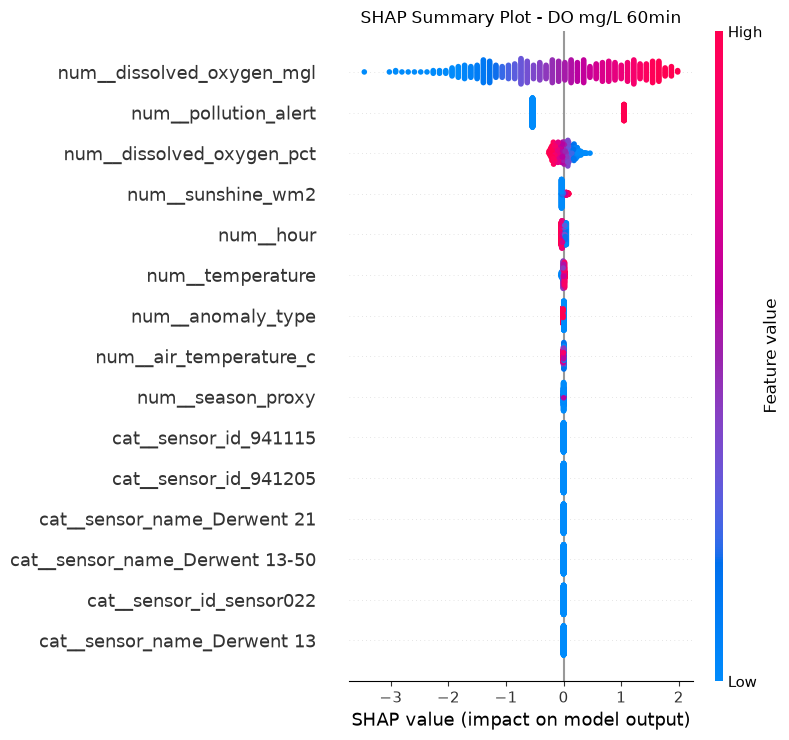

Saved: ../figures/shap\shap_summary_do_mgl_60min.png


In [43]:
shap.summary_plot(
    shap_values,
    X_transformed,
    feature_names=feature_names,
    show=False
)

plt.title(f"SHAP Summary Plot - {TARGET_TYPE} {HORIZON}")
plt.tight_layout()

summary_path = os.path.join(SHAP_OUTPUT_DIR, "shap_summary_do_mgl_60min.png")
plt.savefig(summary_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", summary_path)

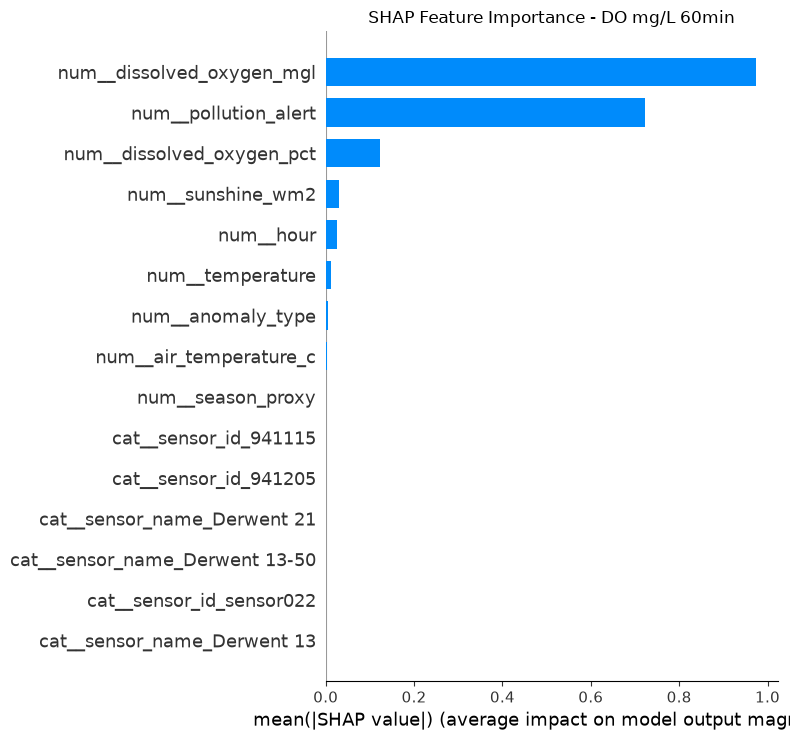

Saved: ../figures/shap\shap_bar_do_mgl_60min.png


In [44]:
shap.summary_plot(
    shap_values,
    X_transformed,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)

plt.title(f"SHAP Feature Importance - {TARGET_TYPE} {HORIZON}")
plt.tight_layout()

bar_path = os.path.join(SHAP_OUTPUT_DIR, "shap_bar_do_mgl_60min.png")
plt.savefig(bar_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", bar_path)

In [45]:
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)

importance_df = pd.DataFrame(
    {
        "feature": feature_names,
        "mean_absolute_shap_value": mean_abs_shap,
    }
).sort_values("mean_absolute_shap_value", ascending=False)

importance_df.head(20)

,feature,mean_absolute_shap_value
4,num__dissolved_oxygen_mgl,0.973946
6,num__pollution_alert,0.722610
5,num__dissolved_oxygen_pct,0.123429
2,num__sunshine_wm2,0.029801
3,num__hour,0.025356
0,num__temperature,0.011346
7,num__anomaly_type,0.006067
1,num__air_temperature_c,0.003409
8,num__season_proxy,0.000104
9,cat__sensor_id_941115,0.000000


In [46]:
importance_output = "../data/processed/shap_feature_importance_do_mgl_60min.csv"

importance_df.to_csv(importance_output, index=False)

print("Saved SHAP feature importance table:")
print(importance_output)

Saved SHAP feature importance table:
../data/processed/shap_feature_importance_do_mgl_60min.csv


Background dataset has 500 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=500 when initializing the masker.


Loading model: ../models\linear_regression_do_pct_60min.pkl


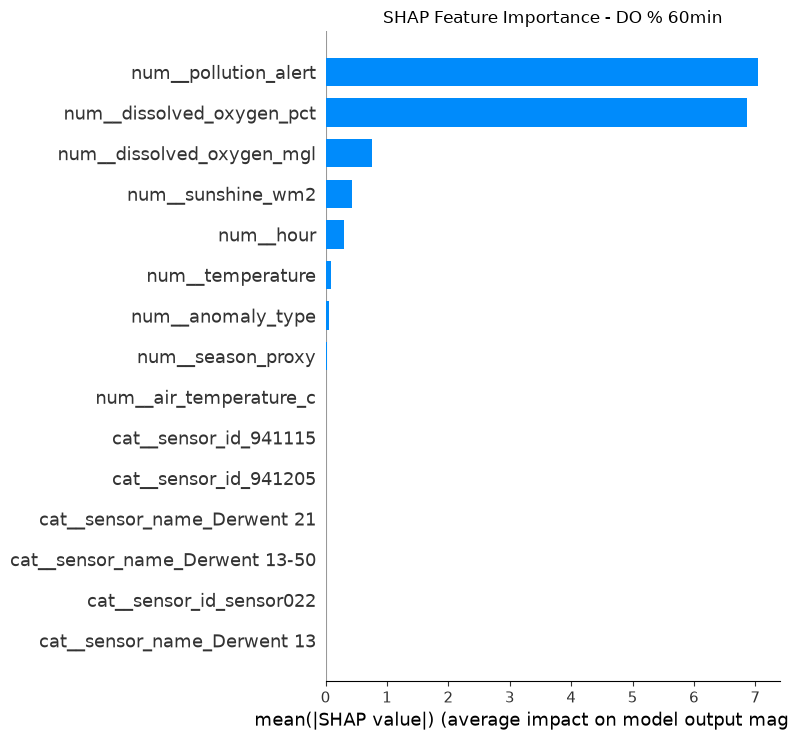

Saved: ../figures/shap\shap_bar_do_pct_60min.png


,feature,mean_absolute_shap_value
6,num__pollution_alert,7.047659
5,num__dissolved_oxygen_pct,6.858680
4,num__dissolved_oxygen_mgl,0.759573
2,num__sunshine_wm2,0.435265
3,num__hour,0.302889
0,num__temperature,0.088484
7,num__anomaly_type,0.051018
8,num__season_proxy,0.013817
1,num__air_temperature_c,0.005041
9,cat__sensor_id_941115,0.000000


In [47]:
TARGET_TYPE = "DO %"
HORIZON = "60min"

selected = metrics[
    (metrics["target_type"] == TARGET_TYPE) &
    (metrics["horizon"] == HORIZON)
].sort_values("RMSE")

best_model_name = selected.iloc[0]["model"]

model_file = (
    f"{safe_filename_text(best_model_name)}_"
    f"{safe_filename_text(TARGET_TYPE)}_"
    f"{HORIZON}.pkl"
)

model_path = os.path.join(MODELS_DIR, model_file)

print("Loading model:", model_path)

model = joblib.load(model_path)

sample_df = df.dropna(subset=[f"do_pct_next_{HORIZON}"]).copy()
sample_df = sample_df.tail(500)

X_sample = sample_df[FEATURES].copy()

preprocessor = model.named_steps["preprocessor"]
trained_model = model.named_steps["model"]

X_transformed = preprocessor.transform(X_sample)

try:
    feature_names = preprocessor.get_feature_names_out()
except:
    feature_names = [f"feature_{i}" for i in range(X_transformed.shape[1])]

explainer = shap.Explainer(trained_model, X_transformed)
shap_values = explainer(X_transformed)

shap.summary_plot(
    shap_values,
    X_transformed,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)

plt.title("SHAP Feature Importance - DO % 60min")
plt.tight_layout()

bar_pct_path = os.path.join(SHAP_OUTPUT_DIR, "shap_bar_do_pct_60min.png")
plt.savefig(bar_pct_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", bar_pct_path)

mean_abs_shap = np.abs(shap_values.values).mean(axis=0)

importance_pct_df = pd.DataFrame(
    {
        "feature": feature_names,
        "mean_absolute_shap_value": mean_abs_shap,
    }
).sort_values("mean_absolute_shap_value", ascending=False)

importance_pct_df.head(20)

In [48]:
importance_pct_output = "../data/processed/shap_feature_importance_do_pct_60min.csv"

importance_pct_df.to_csv(importance_pct_output, index=False)

print("Saved SHAP feature importance table:")
print(importance_pct_output)

Saved SHAP feature importance table:
../data/processed/shap_feature_importance_do_pct_60min.csv


## Summary

This notebook applied SHAP explainability to the dissolved oxygen prediction models.

SHAP was used to identify the features that contributed most strongly to model predictions for:

- DO mg/L at 60 minutes ahead
- DO % at 60 minutes ahead

The main outputs are:

- SHAP summary plots
- SHAP feature importance bar plots
- SHAP feature importance tables

These results can be used in the dissertation to explain which variables most influence the dissolved oxygen forecasting models.